## entropy

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures




df = pd.read_csv("dataset-train-vf.csv")
df = df.drop(columns=["ID"])
df["y"] = df["y"].map({"circle": 1, "square": 0})

X = df.drop(columns=["y"])
y = df["y"]


X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


X_pool_full, X_val, y_pool_full, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)


INITIAL_LABELED = 50
X_labeled, X_pool, y_labeled, y_pool = train_test_split(
    X_pool_full, y_pool_full,
    train_size=INITIAL_LABELED,
    random_state=42,
    stratify=y_pool_full
)


categorical_cols = ["f11"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]



numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False))
])


cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    [("num", numeric_pipe, numeric_cols),
     ("cat", cat_pipe, categorical_cols)],
    remainder="drop"
)


Iter 01 | labeled=  50 | bestC=10.0 | thr=0.695 | Val F1=0.3600
Iter 02 | labeled=  70 | bestC=0.5 | thr=0.877 | Val F1=0.5000
Iter 03 | labeled=  90 | bestC=0.1 | thr=0.552 | Val F1=0.5060
Iter 04 | labeled= 110 | bestC=0.05 | thr=0.832 | Val F1=0.5000
Iter 05 | labeled= 130 | bestC=0.05 | thr=0.832 | Val F1=0.5152
Iter 06 | labeled= 150 | bestC=1.0 | thr=0.493 | Val F1=0.5745
Iter 07 | labeled= 170 | bestC=0.5 | thr=0.645 | Val F1=0.6098
Iter 08 | labeled= 190 | bestC=0.5 | thr=0.616 | Val F1=0.6593
Iter 09 | labeled= 210 | bestC=1.0 | thr=0.680 | Val F1=0.6988
Iter 10 | labeled= 230 | bestC=0.5 | thr=0.591 | Val F1=0.6739
Iter 11 | labeled= 250 | bestC=1.0 | thr=0.616 | Val F1=0.6813
Iter 12 | labeled= 270 | bestC=0.5 | thr=0.566 | Val F1=0.6526
Iter 13 | labeled= 290 | bestC=1.0 | thr=0.591 | Val F1=0.6882
Iter 14 | labeled= 310 | bestC=1.0 | thr=0.606 | Val F1=0.6739
Iter 15 | labeled= 330 | bestC=5.0 | thr=0.709 | Val F1=0.6596
Iter 16 | labeled= 350 | bestC=1.0 | thr=0.576 | Val

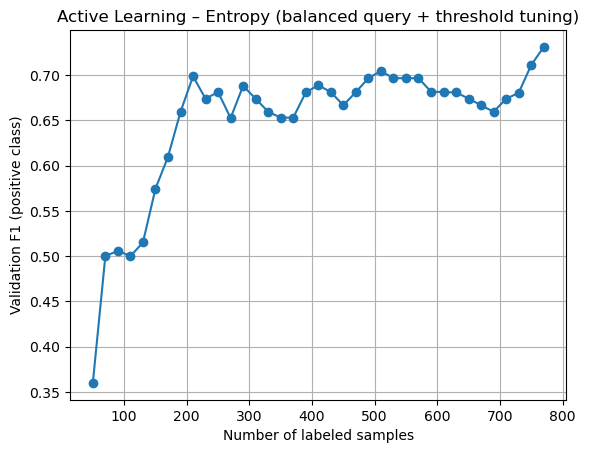

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

def entropy_scores(proba, eps=1e-12):
    p = np.clip(proba, eps, 1.0)
    return -np.sum(p * np.log(p), axis=1)

def best_f1_threshold(y_true, proba, n=200):
    thresholds = np.linspace(0.01, 0.99, n)
    f1s = [f1_score(y_true, (proba >= t).astype(int), pos_label=1) for t in thresholds]
    i = int(np.argmax(f1s))
    return float(thresholds[i]), float(f1s[i])

def fit_select_C_and_threshold(X_labeled, y_labeled, X_val, y_val, C_list):
    best = {"C": None, "thr": None, "f1": -1, "pipe": None}
    for C in C_list:
        model = LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="lbfgs",
            C=C
        )
        pipe = Pipeline([("preprocess", preprocess), ("clf", model)])
        pipe.fit(X_labeled, y_labeled)

        val_proba = pipe.predict_proba(X_val)[:, 1]
        thr, f1v = best_f1_threshold(y_val, val_proba)

        if f1v > best["f1"]:
            best.update({"C": C, "thr": thr, "f1": f1v, "pipe": pipe})
    return best

def query_entropy_balanced(pipe, X_pool, batch_size):
    proba = pipe.predict_proba(X_pool)
    ent = entropy_scores(proba)
    p1 = proba[:, 1]

   
    pos_mask = p1 >= 0.5 #thr but not really
    neg_mask = ~pos_mask

    k_pos = batch_size // 2
    k_neg = batch_size - k_pos

    pos_idx = np.where(pos_mask)[0]
    neg_idx = np.where(neg_mask)[0]

 
    chosen = []

    if len(pos_idx) > 0:
        pos_sorted = pos_idx[np.argsort(ent[pos_idx])]
        chosen.extend(list(pos_sorted[-min(k_pos, len(pos_sorted)):]))

    if len(neg_idx) > 0:
        neg_sorted = neg_idx[np.argsort(ent[neg_idx])]
        chosen.extend(list(neg_sorted[-min(k_neg, len(neg_sorted)):]))

    
    if len(chosen) < batch_size:
        all_sorted = np.argsort(ent)
        for idx in all_sorted[::-1]:
            if idx not in chosen:
                chosen.append(int(idx))
            if len(chosen) == batch_size:
                break

    return np.array(chosen, dtype=int)

# -------------------------
BATCH_SIZE = 20      
MAX_ITERS = 37 #38 
C_LIST = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]


history = []  # (labeled, val_f1)
best_state = None

for it in range(1, MAX_ITERS + 1):
   
    best_state = fit_select_C_and_threshold(X_labeled, y_labeled, X_val, y_val, C_LIST)
    pipe = best_state["pipe"]
    thr = best_state["thr"]
    val_f1 = best_state["f1"]

    history.append((len(y_labeled), val_f1))
    print(f"Iter {it:02d} | labeled={len(y_labeled):4d} | bestC={best_state['C']} | thr={thr:.3f} | Val F1={val_f1:.4f}")

    if len(X_pool) == 0:
        break

    k = min(BATCH_SIZE, len(X_pool))

   
    query_idx = query_entropy_balanced(pipe, X_pool, k)

  
    X_query = X_pool.iloc[query_idx]
    y_query = y_pool.iloc[query_idx]

    X_labeled = pd.concat([X_labeled, X_query], axis=0)
    y_labeled = pd.concat([y_labeled, y_query], axis=0)

    X_pool = X_pool.drop(X_pool.index[query_idx])
    y_pool = y_pool.drop(y_pool.index[query_idx])


final_pipe = best_state["pipe"]
final_thr = best_state["thr"]

test_proba = final_pipe.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= final_thr).astype(int)

print("\n=== FINAL TEST RESULTS ===")
print("Total labeled used:", len(y_labeled))
print("F1 (test):", f1_score(y_test, test_pred, pos_label=1))
print("Accuracy (test):", accuracy_score(y_test, test_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))
print("\nClassification Report:")
print(classification_report(y_test, test_pred))


history = np.array(history, dtype=float)
plt.figure()
plt.plot(history[:, 0], history[:, 1], marker="o")
plt.xlabel("Number of labeled samples")
plt.ylabel("Validation F1 (positive class)")
plt.title("Active Learning – Entropy (balanced query + threshold tuning)")
plt.grid(True)
plt.show()

## least confidence

In [4]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score


train_df = pd.read_csv("dataset-train-vf.csv")
test_df  = pd.read_csv("dataset-test-vf.csv")

y_train_full = (train_df["y"] == "circle").astype(int)
X_train_full = train_df.drop(columns=["y", "ID"])

y_test = None  # test labels are hidden
X_test = test_df.drop(columns=["ID"])

numeric_features = ["f1","f2","f3","f4","f5","f6","f7","f8","f9","f10"]
categorical_features = ["f11"]


numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

#active Learning Setup

np.random.seed(42)

initial_labels = 50
query_size = 30          
max_iterations = 20

all_indices = np.arange(len(X_train_full))
labeled_idx = np.random.choice(all_indices, size=initial_labels, replace=False)
unlabeled_idx = np.setdiff1d(all_indices, labeled_idx)

#model Pipeline
model = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=1000))
])

#least Confidence Sampling

def least_confidence(model, X_pool, n_samples):
    probs = model.predict_proba(X_pool)
    confidence = np.max(probs, axis=1)
    return np.argsort(confidence)[:n_samples]


#active Learning Loop
print("Starting Active Learning (Least Confidence)\n")

for it in range(max_iterations):

    model.fit(X_train_full.iloc[labeled_idx], y_train_full.iloc[labeled_idx])

    train_pred = model.predict(X_train_full.iloc[labeled_idx])
    train_f1 = f1_score(
    y_train_full.iloc[labeled_idx],
    train_pred,
    pos_label=1
    )

    print(f"Iteration {it+1:02d} | "
      f"Labeled samples: {len(labeled_idx):4d} | "
      f"Train F1 (minority): {train_f1:.4f}")


    if len(unlabeled_idx) < query_size:
        break

    # Query most uncertain samples
    pool_X = X_train_full.iloc[unlabeled_idx]
    query_relative_idx = least_confidence(model, pool_X, query_size)
    query_idx = unlabeled_idx[query_relative_idx]

    # Update labeled / unlabeled sets
    labeled_idx = np.concatenate([labeled_idx, query_idx])
    unlabeled_idx = np.setdiff1d(unlabeled_idx, query_idx)

print("\nActive Learning Finished")
print("Total labeled samples used:", len(labeled_idx))


Starting Active Learning (Least Confidence)

Iteration 01 | Labeled samples:   50 | Train F1 (minority): 0.0000
Iteration 02 | Labeled samples:   80 | Train F1 (minority): 0.6000
Iteration 03 | Labeled samples:  110 | Train F1 (minority): 0.8387
Iteration 04 | Labeled samples:  140 | Train F1 (minority): 0.8451
Iteration 05 | Labeled samples:  170 | Train F1 (minority): 0.7629
Iteration 06 | Labeled samples:  200 | Train F1 (minority): 0.7395
Iteration 07 | Labeled samples:  230 | Train F1 (minority): 0.6555
Iteration 08 | Labeled samples:  260 | Train F1 (minority): 0.6154
Iteration 09 | Labeled samples:  290 | Train F1 (minority): 0.6119
Iteration 10 | Labeled samples:  320 | Train F1 (minority): 0.5816
Iteration 11 | Labeled samples:  350 | Train F1 (minority): 0.5960
Iteration 12 | Labeled samples:  380 | Train F1 (minority): 0.5806
Iteration 13 | Labeled samples:  410 | Train F1 (minority): 0.6118
Iteration 14 | Labeled samples:  440 | Train F1 (minority): 0.6230
Iteration 15 | La